In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, Normalizer
from sklearn.pipeline import Pipeline

In [69]:
tf.config.experimental.set_visible_devices([], 'GPU')

In [70]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [71]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [72]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [73]:
y_train = df_train[df_train['label'] == 0]['label']
x_train = df_train[df_train['label'] == 0].drop("label", axis=1)

y_test = df_test['label']
x_test = df_test.drop("label", axis=1)

In [74]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [75]:
print(x_test.shape)
print(x_train.shape)

(82332, 11)
(44800, 11)


In [76]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train = encode_objects(x_train)
x_val = encode_objects(x_val)
x_test = encode_objects(x_test)

In [77]:
pipeline = Pipeline([('normalizer', Normalizer()),
                     ('scaler', MinMaxScaler())])

In [78]:
pipeline.fit(x_train)

Pipeline(steps=[('normalizer', Normalizer()), ('scaler', MinMaxScaler())])

In [79]:
x_train_transformed = pipeline.transform(x_train)
x_val_transformed = pipeline.transform(x_val)

In [80]:
# Load the extension and start TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 30912), started 0:18:29 ago. (Use '!kill 30912' to kill it.)

In [81]:
# data dimensions // hyperparameters 
input_dim = x_train_transformed.shape[1]
BATCH_SIZE = 128
EPOCHS = 50

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Dense(input_dim, activation='elu', input_shape=(input_dim, )), 
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(2, activation='elu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(input_dim, activation='elu')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 11)                132       
                                                                 
 dense_8 (Dense)             (None, 8)                 96        
                                                                 
 dense_9 (Dense)             (None, 4)                 36        
                                                                 
 dense_10 (Dense)            (None, 2)                 10        
                                                                 
 dense_11 (Dense)            (None, 4)                 12        
                                                                 
 dense_12 (Dense)            (None, 8)                 40        
                                                                 
 dense_13 (Dense)            (None, 11)               

In [82]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='autoencoder_best_weights.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

In [83]:
history = autoencoder.fit(
    x_train_transformed, x_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_transformed, x_val_transformed)
)

Epoch 1/50
350/350 [==============================] - 4s 8ms/step - loss: 0.0239 - acc: 0.8918 - val_loss: 0.0025 - val_acc: 0.9390
Epoch 2/50
 17/350 [>.............................] - ETA: 2s - loss: 0.0028 - acc: 0.9306

/mnt/c/Users/David/OneDrive - Technical University of Cluj-Napoca/Desktop/David/university/ETTI/Thesis/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


350/350 [==============================] - 3s 7ms/step - loss: 0.0021 - acc: 0.9389 - val_loss: 0.0019 - val_acc: 0.9387
Epoch 3/50
350/350 [==============================] - 2s 6ms/step - loss: 0.0016 - acc: 0.9423 - val_loss: 0.0012 - val_acc: 0.9444
Epoch 4/50
350/350 [==============================] - 2s 5ms/step - loss: 0.0010 - acc: 0.9481 - val_loss: 9.4843e-04 - val_acc: 0.9471
Epoch 5/50
350/350 [==============================] - 2s 5ms/step - loss: 8.9294e-04 - acc: 0.9661 - val_loss: 9.0212e-04 - val_acc: 0.9930
Epoch 6/50
350/350 [==============================] - 2s 5ms/step - loss: 8.5908e-04 - acc: 0.9723 - val_loss: 8.6582e-04 - val_acc: 0.9567
Epoch 7/50
350/350 [==============================] - 2s 5ms/step - loss: 8.1528e-04 - acc: 0.9619 - val_loss: 8.0525e-04 - val_acc: 0.9472
Epoch 8/50
350/350 [==============================] - 2s 5ms/step - loss: 7.3870e-04 - acc: 0.9569 - val_loss: 7.0292e-04 - val_acc: 0.9481
Epoch 9/50
350/350 [==============================]

In [84]:
x_test_transformed = pipeline.transform(x_test)

reconstructions = autoencoder.predict(x_test_transformed)

2573/2573 [==============================] - 5s 2ms/step


In [85]:
mse = np.mean(np.power(x_test_transformed - reconstructions, 2), axis=1)

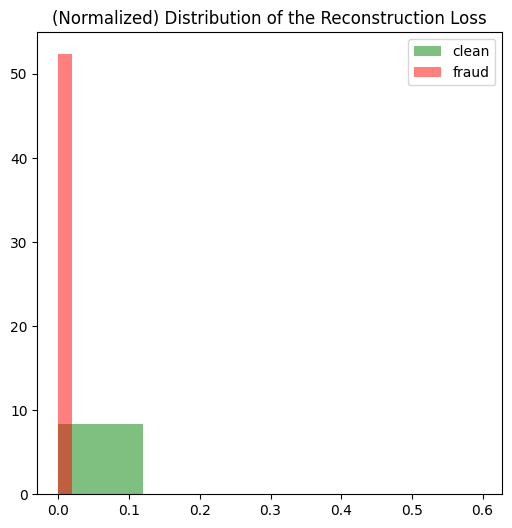

In [87]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [93]:
THRESHOLD = 5

def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD


In [94]:
from sklearn.metrics import confusion_matrix, precision_recall_curve

# get (mis)classification
cm = confusion_matrix(y_test, outliers)

# true/false positives/negatives
print(cm.flatten())

[17244 19756 29602 15730]
